In [ ]:
"""
Animates a regional timeseries, for a given IR channel, of brightness
temperature and its log_grad, overlaid with cloud mask.

Coded by Lucie Reymondet (Scripps-UCSD) and adapted by M. du Plessis (University of Gothenburg)
"""

# ----- Imports
from pathlib import Path
import datetime
import numpy as np
import pandas as pd
import xarray as xr
import os
import re
import glob
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from matplotlib import gridspec
import cmocean

import cartopy.crs as ccrs

from params import base_dir, processed_goflow_inputs,\
    lon_min, lon_max, lat_min, lat_max, resolution 
# from calc_vector_grad import UVgrad
from plot_utils import plt_args, format_axes, add_box

# --------------------------------
#  Initialization
# --------------------------------
channel = "ir_105"
# channel = "ir_123"
VARS = ["BT", "loggrad_T", "loggrad_T_masked"]#, "vort", "div"] #


# ----- Plotting parameters
cbar_labelsize = 7
cbar_ticksize = 6
insert_fontsize = 8
letter_box_size = 8
letter_size = 6
# from plot_utils import parameters
# plt.rcParams.update(parameters)

alpha = 20
quiverscale = 3e-5
quiverwidth = 0.001
headwidth = 3
wind_scale = 10 * 110e3  # 10°

# -----------------------------
# DIRECTORIES
# -----------------------------
def fmt_lon(v):
    return f"{abs(v):.0f}{'E' if v >= 0 else 'W'}"

def fmt_lat(v):
    return f"{abs(v):.0f}{'N' if v >= 0 else 'S'}"

area_label = f"{fmt_lon(lon_min)}-{fmt_lon(lon_max)}_{fmt_lat(lat_min)}-{fmt_lat(lat_max)}"

DIR_IN = os.path.join(processed_goflow_inputs, area_label)

# base_dir = Path(__file__).resolve().parent.parent
base_dir = '/home/mduplessis/projects/DOWNLOAD_EUMETSAT/'
DIR_OUT = os.path.join(base_dir, "figures")
os.makedirs(DIR_OUT, exist_ok=True)

# -----------------------------
# DATA
# -----------------------------
def parse_timespan_from_name(path):
    name = os.path.basename(path)
    match = re.match(r"(\d{12})-(\d{12})_", name)
    if not match:
        return None
    start = datetime.datetime.strptime(match.group(1), "%Y%m%d%H%M")
    end = datetime.datetime.strptime(match.group(2), "%Y%m%d%H%M")
    return start, end


def files_last_48h(directory, pattern):
    now = datetime.datetime.now()
    window_start = now - datetime.timedelta(hours=48)

    candidates = glob.glob(os.path.join(directory, pattern))
    selected = []
    for path in candidates:
        span = parse_timespan_from_name(path)
        if span is None:
            continue
        start, end = span
        if end >= window_start and start <= now:
            selected.append((start, path))

    selected.sort(key=lambda item: item[0])
    return [item[1] for item in selected]


file_pattern = f"*_FCI-{channel}_{str(resolution).replace('.', 'p')}deg.nc"
selected_files = files_last_48h(DIR_IN, file_pattern)

if not selected_files:
    raise FileNotFoundError(
        f"No files found in the last 48h for pattern {file_pattern} in {DIR_IN}"
    )

print("Using files:")
for p in selected_files:
    print(f"  {os.path.basename(p)}")

datasets = [xr.open_dataset(p) for p in selected_files]
ds = xr.concat(datasets, dim="time").sortby("time")

time_index = ds.get_index("time")
if time_index.has_duplicates:
    ds = ds.isel(time=~time_index.duplicated())

# u_da = ds["U"]
# v_da = ds["V"]
# _, div, vort, _ = UVgrad(u_da, v_da)
# ds["vort"] = vort
# ds["div"] = div

times = ds.time.values
n_times = ds.sizes["time"]

In [2]:
ds_subset = ds.sel(lat=slice(-38, -30), lon=slice(10, 20))

In [18]:
ds_subset

<xarray.Dataset> Size: 115MB
Dimensions:           (time: 36, lat: 400, lon: 500)
Coordinates:
  * time              (time) datetime64[ns] 288B 2026-06-04T18:00:00 ... 2026...
  * lat               (lat) float64 3kB -37.99 -37.97 -37.95 ... -30.03 -30.01
  * lon               (lon) float64 4kB 10.01 10.03 10.05 ... 19.95 19.97 19.99
Data variables:
    BT                (time, lat, lon) float32 29MB ...
    loggrad_T         (time, lat, lon) float32 29MB ...
    mask              (time, lat, lon) float32 29MB ...
    loggrad_T_masked  (time, lat, lon) float32 29MB ...
Attributes:
    title:        FCI ir_105 brightness temperature, gradient, and cloud mask
    source:       RRAD: 202606041800-202606042350_FCI-1C-RRAD_0p02deg.nc; CLM...
    Conventions:  CF-1.8

In [6]:
ds

<xarray.Dataset> Size: 540MB
Dimensions:           (time: 36, lat: 750, lon: 1250)
Coordinates:
  * time              (time) datetime64[ns] 288B 2026-06-04T18:00:00 ... 2026...
  * lat               (lat) float64 6kB -44.99 -44.97 -44.95 ... -30.03 -30.01
  * lon               (lon) float64 10kB 10.01 10.03 10.05 ... 34.95 34.97 34.99
Data variables:
    BT                (time, lat, lon) float32 135MB ...
    loggrad_T         (time, lat, lon) float32 135MB ...
    mask              (time, lat, lon) float32 135MB ...
    loggrad_T_masked  (time, lat, lon) float32 135MB ...
Attributes:
    title:        FCI ir_105 brightness temperature, gradient, and cloud mask
    source:       RRAD: 202606041800-202606042350_FCI-1C-RRAD_0p02deg.nc; CLM...
    Conventions:  CF-1.8

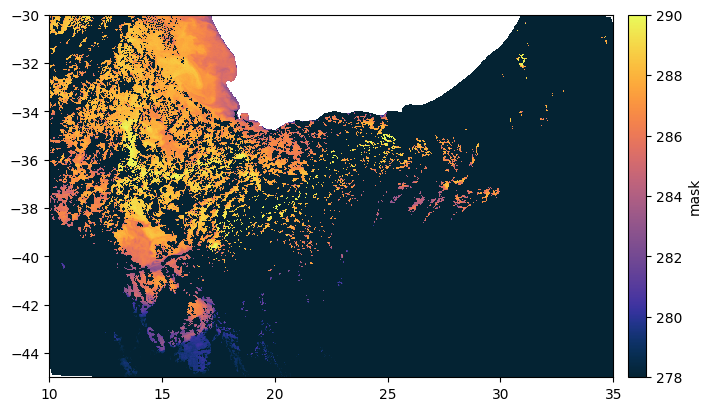

In [3]:
fig, ax = plt.subplots(figsize=(7, 4), constrained_layout=True)

ax.pcolor = ax.pcolormesh(ds.lon, ds.lat, ds["BT"].isel(time=1) * ds["mask"].isel(time=1), cmap=cmocean.cm.thermal, vmin=278, vmax=290)
plt.colorbar(ax.pcolor, ax=ax, label="mask", pad=0.01)


In [11]:
data0.min()

<xarray.DataArray 'loggrad_T_masked' ()> Size: 4B
array(-6.6460433, dtype=float32)
Coordinates:
    time     datetime64[ns] 8B 2026-06-04T18:00:00
Attributes:
    standard_name:       latitude
    long_name:           Log10 horizontal gradient magnitude of ir_105 BT, ma...
    units:               log10(K/m)
    source_channel:      ir_105
    source_calibration:  brightness_temperature
    gradient_method:     central differences via xarray.differentiate, spheri...
    eps:                 1e-12
    masking:             NaN where mask==0 (CLM=2, cloudy) only

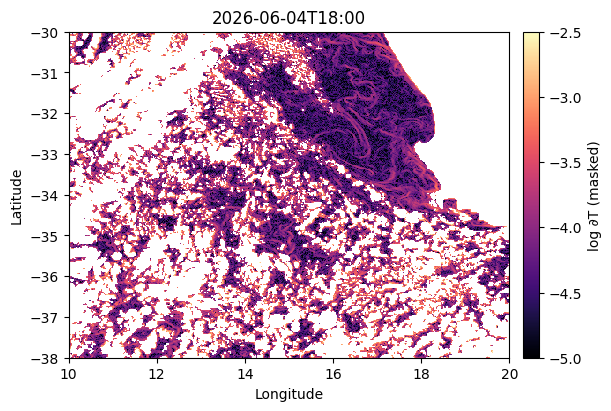

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import cmocean

var = "loggrad_T_masked"
cmap = "magma"

fig, ax = plt.subplots(figsize=(6, 4), constrained_layout=True)

# first frame
# data0 = (ds["BT"] * ds["mask"]).isel(time=0)
# data0 = (ds_subset["BT"] * ds_subset["mask"]).isel(time=0)
data0 = ds_subset[var].isel(time=0)

pcm = ax.pcolormesh(
    ds_subset.lon,
    ds_subset.lat,
    data0,
    cmap=cmap,
    vmin=-5,
    vmax=-2.5,
    shading="auto",
)

cbar = plt.colorbar(pcm, ax=ax, pad=0.01)
cbar.set_label("log ∂T (masked)")

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
title = ax.set_title(f"{np.datetime_as_string(ds_subset.time.values[0], unit='m')}")

def update(frame):
    data = ds_subset[var].isel(time=frame).values
    pcm.set_array(data.ravel())
    title.set_text(np.datetime_as_string(ds_subset.time.values[frame], unit='m'))
    return pcm, title

ani = FuncAnimation(
    fig,
    update,
    frames=ds_subset.sizes["time"],
    interval=300,
    blit=False,
    repeat=True,
)

ani.save(f"/home/mduplessis/projects/whirls-monitoring/eumetsat_sst/figures/goflow_sst_{var}_animation.gif", writer="pillow", fps=4, dpi=200)


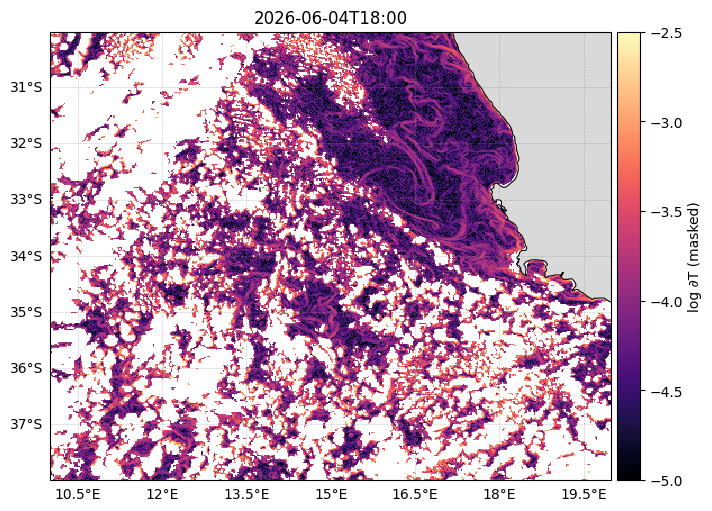

In [19]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean


var = "loggrad_T_masked"
cmap = "magma"

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(7, 5), constrained_layout=True)
ax = plt.axes(projection=proj)

# Optional: zoom map to your data domain
ax.set_extent(
    [
        float(ds_subset.lon.min()),
        float(ds_subset.lon.max()),
        float(ds_subset.lat.min()),
        float(ds_subset.lat.max()),
    ],
    crs=ccrs.PlateCarree(),
)

ax.coastlines(resolution="10m", linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=0)
gl = ax.gridlines(draw_labels=True, linewidth=0.4, color="gray", alpha=0.5, linestyle="--")
gl.top_labels = False
gl.right_labels = False

# first frame
data0 = ds_subset[var].isel(time=0)

pcm = ax.pcolormesh(
    ds_subset.lon,
    ds_subset.lat,
    data0,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    vmin=-5,
    vmax=-2.5,
    shading="auto",
)

cbar = plt.colorbar(pcm, ax=ax, pad=0.01)
cbar.set_label("log ∂T (masked)")

title = ax.set_title(np.datetime_as_string(ds_subset.time.values[0], unit="m"))


def update(frame):
    data = ds_subset[var].isel(time=frame).values
    pcm.set_array(data.ravel())
    title.set_text(np.datetime_as_string(ds_subset.time.values[frame], unit="m"))
    return pcm, title


ani = FuncAnimation(
    fig,
    update,
    frames=ds_subset.sizes["time"],
    interval=300,
    blit=False,
    repeat=True,
)

ani.save(
    f"/home/mduplessis/projects/whirls-monitoring/eumetsat_sst/figures/goflow_sst_{var}_animation.gif",
    writer="pillow",
    fps=4,
    dpi=200,
)

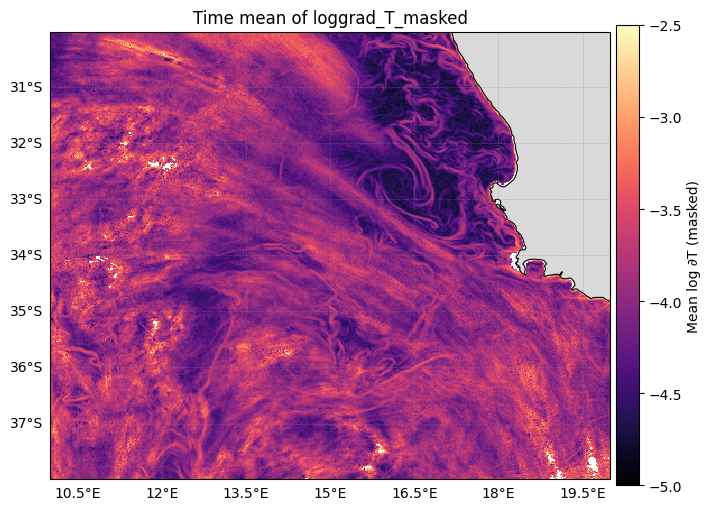

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean

var = "loggrad_T_masked"
cmap = "magma"

proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(7, 5), constrained_layout=True)
ax = plt.axes(projection=proj)

ax.set_extent(
    [
        float(ds_subset.lon.min()),
        float(ds_subset.lon.max()),
        float(ds_subset.lat.min()),
        float(ds_subset.lat.max()),
    ],
    crs=ccrs.PlateCarree(),
)

ax.coastlines(resolution="10m", linewidth=0.8)
ax.add_feature(cfeature.LAND, facecolor="0.85", zorder=0)

gl = ax.gridlines(
    draw_labels=True,
    linewidth=0.4,
    color="gray",
    alpha=0.5,
    linestyle="--"
)
gl.top_labels = False
gl.right_labels = False

# Average over all time steps
data_mean = ds_subset[var].mean(dim="time")

pcm = ax.pcolormesh(
    ds_subset.lon,
    ds_subset.lat,
    data_mean,
    transform=ccrs.PlateCarree(),
    cmap=cmap,
    vmin=-5,
    vmax=-2.5,
    shading="auto",
)

cbar = plt.colorbar(pcm, ax=ax, pad=0.01)
cbar.set_label("Mean log ∂T (masked)")

ax.set_title(f"Time mean of {var}")

plt.savefig(
    f"/home/mduplessis/projects/whirls-monitoring/eumetsat_sst/figures/goflow_sst_{var}_mean_map.png",
    dpi=200,
    bbox_inches="tight",
)
plt.show()

In [ ]:










# ----- Domain
lon, lat = ds['lon'].values, ds['lat'].values
lon_grid, lat_grid = np.meshgrid(lon, lat)
lat_mean = np.mean(lat)
Nx = len(lon)

# ----- Train / Test / Validation regions
ll_corner = (100, 100, 100, 100)
train_inds = [
    tuple(a + b for a, b in zip(t, ll_corner))
    for t in [
        (0, 256, 0, 256),
        (0, 256, 256, 512),
        (256, 512, 0, 256),
        (256, 512, 256, 512),
        (256, 512, 512, 768),
    ]
]
test_inds = [
    tuple(a + b for a, b in zip((0, 256, 512, 768), ll_corner))
]
valid_inds = tuple(
    a + b for a, b in zip((0, 512, Nx - 768, Nx), ll_corner)
)

# -----------------------------
# PLOT
# -----------------------------
ncols = 2
nrows = 2
widths = np.ones(ncols)
heights = np.ones(nrows)
hpad, wpad = 0.02, 0.2

fig = plt.figure(figsize=(6, 3 * nrows))
gs = gridspec.GridSpec(nrows, ncols, height_ratios=heights, hspace=hpad, wspace=wpad)
axs_map = np.array([
    fig.add_subplot(gs[i, j], projection=ccrs.PlateCarree())
    for i in range(nrows)
    for j in range(ncols)
])
# qp = np.empty_like(axs_map, dtype=object)

# ----- Draw static elements (gridlines, boxes, labels) using time=0
for v, variable in enumerate(VARS):
    ax = axs_map[v]
    ax.set_aspect(1 / np.cos(np.deg2rad(lat_mean)))
    format_axes(ax, 0, 0)
    ax.coastlines(resolution='50m', color='black', linewidth=0.4)
    # Panel letters
    txq, tyq = 0.05, 0.93
    tt = ax.text(txq, tyq, '   ', weight="bold", size=letter_box_size,
                 horizontalalignment='center', verticalalignment='center',
                 transform=ax.transAxes,
                 bbox=dict(boxstyle="round", fc="white", ec="black", pad=0.1))
    tt.set_zorder(3)
    tt = ax.text(txq, tyq, chr(97 + v), weight="bold", size=letter_size,
                 horizontalalignment='center', verticalalignment='center',
                 transform=ax.transAxes)

# ----- Train / test boxes on panel a
for inds in train_inds:
    add_box(axs_map[0], inds, lon, lat, 'cyan')
for inds in test_inds:
    add_box(axs_map[0], inds, lon, lat, 'k')
# add_box(ax, valid_inds, lon, lat, 'lime')

# ----- Create initial pcolormesh objects (time=0)
meshes = []
for v, variable in enumerate(VARS):
    ax = axs_map[v]
    vmin, vmax, extend, units, title, cmap, scale, gl_color = plt_args(variable)
    data = ds[variable].isel(time=0).values * scale
    if variable=="BT":
        data -= 273 # convert to celsius
    cm = ax.pcolormesh(lon_grid, lat_grid, data,
                       shading='nearest', vmin=vmin, vmax=vmax,
                       cmap=cmap, transform=ccrs.PlateCarree())
    cbar = fig.colorbar(cm, ax=ax, orientation='horizontal',
                        extend=extend, pad=0.05, fraction=0.04)
    cbar.set_label(f'{title} [{units}]', fontsize=cbar_labelsize)
    cbar.ax.tick_params(labelsize=cbar_ticksize)
    meshes.append(cm)

# # ----- Initial quiver (time=0)
# u = ds["U"].isel(time=0).values
# v = ds["V"].isel(time=0).values
# u_qv = u[::alpha, ::alpha] / wind_scale
# v_qv = v[::alpha, ::alpha] / wind_scale
# lon_grid_qv = lon_grid[::alpha, ::alpha]
# lat_grid_qv = lat_grid[::alpha, ::alpha]
# qp[0] = axs_map[0].quiver(lon_grid_qv, lat_grid_qv, u_qv, v_qv,
#                            width=quiverwidth, scale=quiverscale,
#                            headwidth=headwidth, color='cyan')

# # ----- Quiver key
# ax = axs_map[0]
# txq, tyq = 0.86, 0.9
# tt = ax.text(txq, tyq, '             \n', weight="bold", size=8,
#              horizontalalignment='center', verticalalignment='center',
#              transform=ax.transAxes,
#              bbox=dict(boxstyle="round", fc="white", ec="black", pad=0.05))
# tt.set_zorder(2)
# tt = ax.text(txq, tyq + 0.05, 'Surface current', weight="bold", size=4,
#              horizontalalignment='center', verticalalignment='center',
#              transform=ax.transAxes)
# tt.set_zorder(2)
# lkey = 1
# qt = ax.quiverkey(qp[0], X=txq, Y=tyq - 0.05, U=lkey / wind_scale,
#                   label=str(lkey) + r' m s$^{-1}$',
#                   fontproperties={'size': 3}, labelsep=0.05, coordinates="axes")
# qt.set_zorder(3)

# # ----- Time label (top of figure)
time_text = axs_map[1].text(0.5, 1.08, pd.to_datetime(times[0]).strftime("%Y-%m-%d %H:%M"),
                             ha='center', va='bottom', fontsize=7, weight='bold',
                             transform=axs_map[1].transAxes)

# --------------------------------
#  Animation update function
# --------------------------------

def update(frame):
    # Update each pcolormesh
    for v, variable in enumerate(VARS):
        _, _, _, _, _, _, scale, _ = plt_args(variable)
        data = ds[variable].isel(time=frame).values * scale
        if variable=="BT":
            data -= 273 # convert to celsius
        meshes[v].set_array(data.ravel())

    # Update quiver
    # u = ds["U"].isel(time=frame).values
    # v_arr = ds["V"].isel(time=frame).values
    # u_qv = u[::alpha, ::alpha] / wind_scale
    # v_qv = v_arr[::alpha, ::alpha] / wind_scale
    # qp[0].set_UVC(u_qv, v_qv)

    # Update time label
    time_text.set_text(pd.to_datetime(times[frame]).strftime("%Y-%m-%d %H:%M"))

    return meshes + [time_text] #+ [qp[0]] 


# ----- Build and save animation
interval_ms = 200  # ms per frame

anim = animation.FuncAnimation(
    fig,
    update,
    frames=n_times,
    interval=interval_ms,
    blit=False  # blit=False needed for cartopy axes
)

# -----------------------------
# SAVE
# -----------------------------
outfile = os.path.join(DIR_OUT, f"{channel}_snapshot_animation.gif")

writer = animation.PillowWriter(fps=5)
anim.save(outfile, writer=writer, dpi=150)

plt.close(fig)
print(f"Saved animation to {outfile}")